---
title: C.3re tanglegrams 
author: Elgin Akin
date: 2025-05-19
---

Useful resources: 
- [baltic](https://github.com/evogytis/baltic/blob/master/docs/notebooks/austechia.ipynb)
- [A nice blog by Gytis on reassortment](https://evogytis.github.io/posts/2020/10/reassortment/)

# Global Notebook Parameters


In [ ]:
# Subclade Colors

subclade_colors = {
            "C.5.1": "#e7298a",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#2E6F40",
            "C.2": "#7570b3",
            "C": "#d95f02"
        }


subclade_colors = {
            "C.5.1": "#d95f02",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#00A7E1",
            "C.2": "#7570b3",
            "C": "#e7298a"
        }


# C.5.4
# C.5.3
# C.5.2
# C.4  

# All A.X lineages

# Plot HA colored by subclade


Tree height: 8.921817
Tree length: 1359.867001
annotations present

Numbers of objects in tree: 4625 (2290 nodes and 2335 leaves)



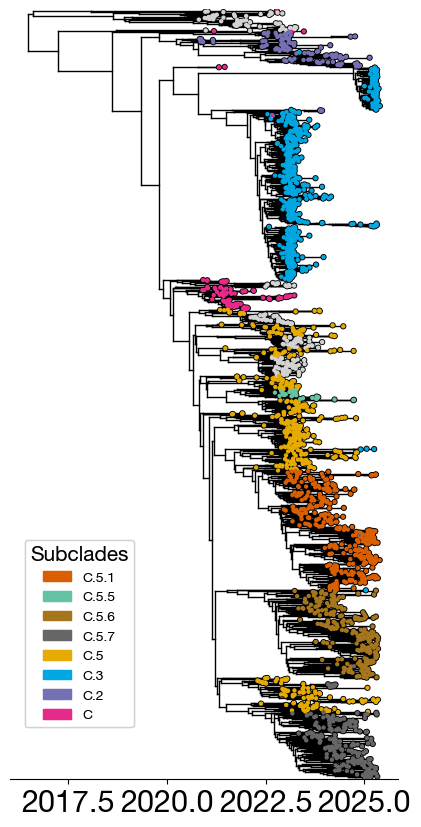

In [3]:
import baltic as bt
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches

# set global fonts 

typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22

# Load tree
genome = "../auspice/vic/genome.json"

tree= bt.loadJSON(genome)

# Define your subclade color palette
subclade_colors = {
            "C.5.1": "#d95f02",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#00A7E1",
            "C.2": "#7570b3",
            "C": "#e7298a"
        }

# Define a color function for the tips
def c_func(node):
    subclade = node.traits.get('subclade')  # Get the 'subclade' attribute
    return subclade_colors.get(subclade, 'lightgrey')  # Default to grey if subclade is not in the palette

L=len(list(filter(lambda k: k.branchType=='leaf',tree[0].Objects)))
b_func=lambda k: 2+10.0*len(k.leaves)/float(L) if k.branchType=='node' else 2 ## branch width is determined by how many descendants a node has, otherwise 2 (tips)

fig, ax = plt.subplots(figsize=(5, 10), facecolor='w')

x_attr = lambda k: k.absoluteTime  # Use absolute time for x-axis

# Plot the tree and tips
tree[0].plotTree(ax,
                connection_type = "baltic",
                x_attr=x_attr, 
                colour='k',  # Plot tree branches in black
                width = 1,
                #width = b_func,
                #colour = c_func)
                )
tree[0].plotPoints(ax, 
                x_attr=x_attr, 
                size=10, 
                outline = True,
                outline_colour = "black", 
                colour=c_func, 
                zorder=100)  # Color tips based on subclade

# Subclade legend with precise positioning
subclade_legend = ax.legend(handles=[mpatches.Patch(color=color,
                                            label=subclade) for subclade, color in subclade_colors.items()], 
                                            title="Subclades", 
                                            title_fontsize=15,
                                            bbox_to_anchor=(0.02, 0.32),
                                            loc='upper left', 
                                            fontsize=10)

ax.add_artist(subclade_legend)  # Ensures the first legend stays

# Aesthetics
ax.xaxis.tick_bottom()
ax.set_ylim(-5, tree[0].ySpan + 5)  # Adjust y-axis limits
ax.set_yticks([])  # Remove y-axis ticks
ax.set_yticklabels([])  # Remove y-axis labels
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]  # Hide spines except bottom

#plt.savefig('../figures/01_B_genome-tree-baltic',dpi=300, bbox_inches='tight')
plt.show()


Tree height: 7.945229
Tree length: 1088.259765
annotations present

Numbers of objects in tree: 3984 (1649 nodes and 2335 leaves)



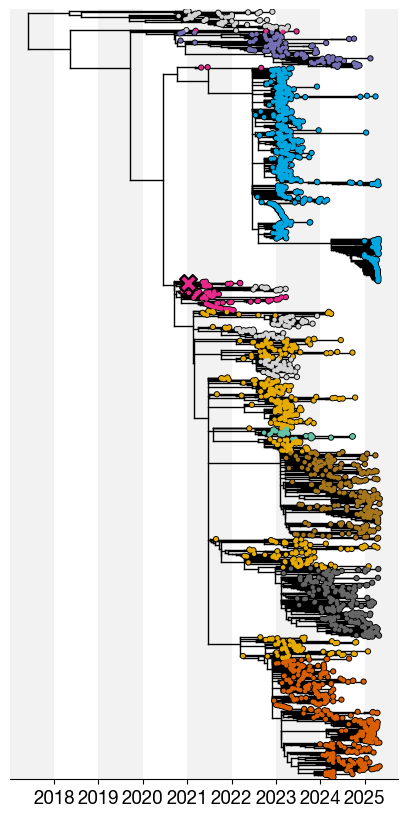


Tree height: 9.688370
Tree length: 1264.891625
annotations present

Numbers of objects in tree: 3828 (1493 nodes and 2335 leaves)



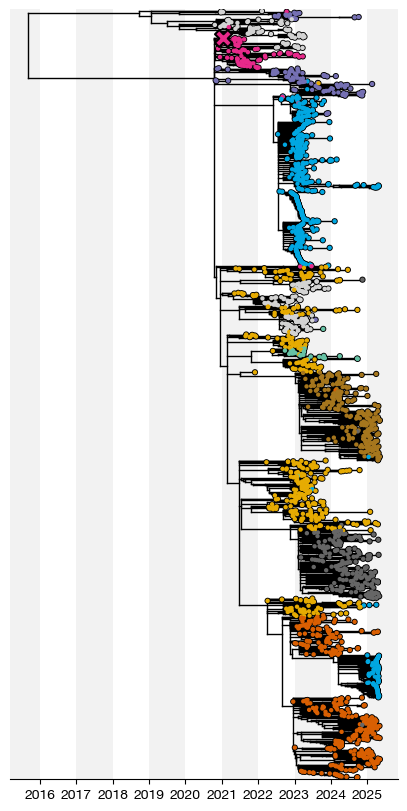


Tree height: 4.669080
Tree length: 1585.503636
annotations present

Numbers of objects in tree: 4055 (1720 nodes and 2335 leaves)



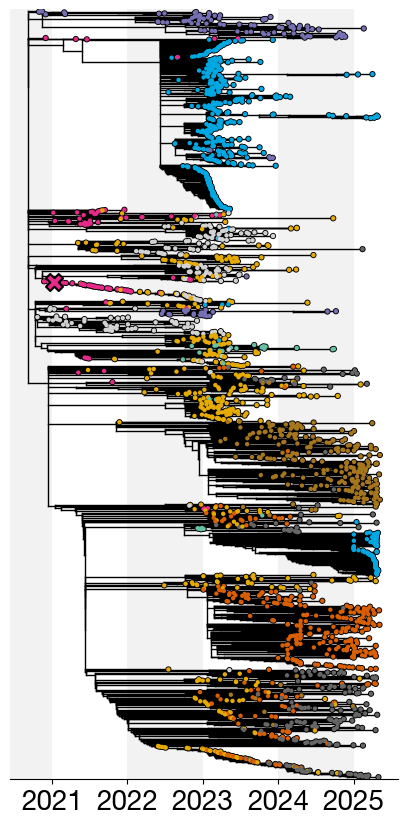


Tree height: 8.921817
Tree length: 1359.867001
annotations present

Numbers of objects in tree: 4625 (2290 nodes and 2335 leaves)



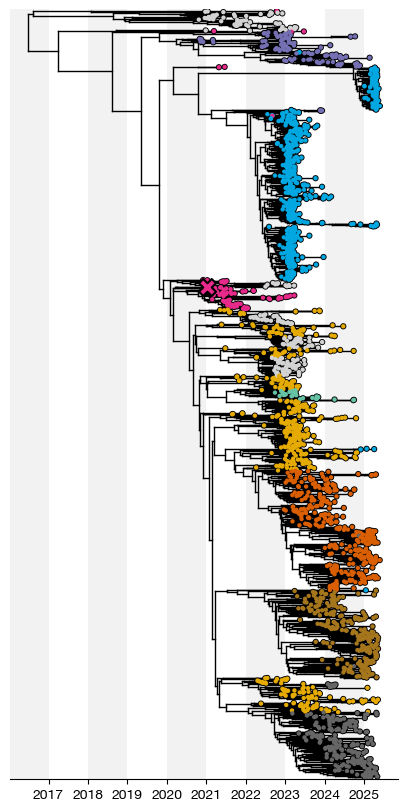

In [34]:
import baltic as bt
import matplotlib as mpl
import matplotlib.pyplot as plt

# Set global fonts once (can be done outside the function)
typeface = 'Helvetica Neue'
mpl.rcParams['font.weight'] = 200
mpl.rcParams['axes.labelweight'] = 300
mpl.rcParams['font.family'] = typeface
mpl.rcParams['font.size'] = 22

def plot_influenza_tree(
    tree_file,
    vaccine_strain="B/Austria/1359417/2021-E3(Am2/Al1)",
    subclade_colors=None,
    figsize=(5, 10),
    add_labels=False,
    label_distance=0.8,
    x_labelsize=14
):
    # Default subclade color palette if none provided
    if subclade_colors is None:
        subclade_colors = {
            "C.5.1": "#d95f02",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#00A7E1",
            "C.2": "#7570b3",
            "C": "#e7298a"
        }
    
    # Load tree
    tree = bt.loadJSON(tree_file)
    
    # Define color function for tips by subclade
    def c_func(node):
        subclade = node.traits.get('subclade')
        return subclade_colors.get(subclade, 'lightgrey')

    # Prepare figure and axis
    fig, ax = plt.subplots(figsize=figsize, facecolor='w')

    x_attr = lambda k: k.absoluteTime

    # Plot tree branches
    tree[0].plotTree(ax, connection_type="baltic", x_attr=x_attr, colour='k', width=1)
    # Plot tips colored by subclade
    tree[0].plotPoints(ax, x_attr=x_attr, size=10, outline=True, outline_colour="black", colour=c_func, zorder=100)

    # Get min and max year from all nodes (tips + internal)
    all_dates = [k.absoluteTime for k in tree[0].Objects]
    min_year = int(min(all_dates))
    max_year = int(max(all_dates)) + 1

    # Add alternating grey and white background bars by year
    for i, year in enumerate(range(min_year, max_year)):
        if i % 2 == 0:
            ax.axvspan(year, year + 1, facecolor='grey', alpha=0.1, edgecolor='none')
        else:
            ax.axvspan(year, year + 1, facecolor='white', alpha=0, edgecolor='none')

    # Set x-axis ticks and labels as years
    years = list(range(min_year, max_year))
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years])

    for k in tree[0].Objects:
        if k.is_leaf() and k.name == vaccine_strain:
            x = k.absoluteTime
            y = k.y
            ax.scatter(
                x, y,
                s=150,
                marker='X',
                facecolors=subclade_colors["C"],
                edgecolors='black',
                linewidths=1.5,
                zorder=200
            )
            break
    # Optionally add labels with connecting lines (not active by default)
    if add_labels:
        max_x = max(k.absoluteTime for k in tree[0].Objects if k.is_leaf())
        label_x = max_x + label_distance
        for k in tree[0].Objects:
            if k.is_leaf():
                ax.plot([k.absoluteTime, label_x], [k.y, k.y], color='gray', linestyle=':', linewidth=1)
                ax.text(label_x + 0.1, k.y, k.name, va='center', ha='left', size=10, color='black')


    
    # Aesthetics cleanup
    ax.xaxis.tick_bottom()
    ax.tick_params(axis='x', labelsize=x_labelsize)
    ax.set_ylim(-5, tree[0].ySpan + 5)
    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]

    plt.show()

# Example usage:
plot_influenza_tree("../auspice/vic/ha.json", x_labelsize=13.5)
plot_influenza_tree("../auspice/vic/na.json", x_labelsize=10)
plot_influenza_tree("../auspice/vic/ns.json", x_labelsize=20)
plot_influenza_tree("../auspice/vic/genome.json", x_labelsize=10)
#plot_influenza_tree("../auspice/vic/ha.json", x_labelsize=20)
#plot_influenza_tree("../auspice/vic/np.json", x_labelsize=20)
#plot_influenza_tree("../auspice/vic/na.json", x_labelsize=20)
#plot_influenza_tree("../auspice/vic/mp.json", x_labelsize=20)
#plot_influenza_tree("../auspice/vic/ns.json", x_labelsize=20)


## Grid-like Function


Tree height: 9.310130
Tree length: 1255.505661
annotations present

Numbers of objects in tree: 3857 (1522 nodes and 2335 leaves)


Tree height: 7.095150
Tree length: 1184.972572
annotations present

Numbers of objects in tree: 3831 (1496 nodes and 2335 leaves)


Tree height: 6.654375
Tree length: 1011.683817
annotations present

Numbers of objects in tree: 3992 (1657 nodes and 2335 leaves)


Tree height: 7.945229
Tree length: 1088.259765
annotations present

Numbers of objects in tree: 3984 (1649 nodes and 2335 leaves)


Tree height: 5.925137
Tree length: 1200.355876
annotations present

Numbers of objects in tree: 3992 (1657 nodes and 2335 leaves)


Tree height: 9.688370
Tree length: 1264.891625
annotations present

Numbers of objects in tree: 3828 (1493 nodes and 2335 leaves)


Tree height: 11.395142
Tree length: 1433.933887
annotations present

Numbers of objects in tree: 4004 (1669 nodes and 2335 leaves)


Tree height: 4.669080
Tree length: 1585.503636
annotations present

Number

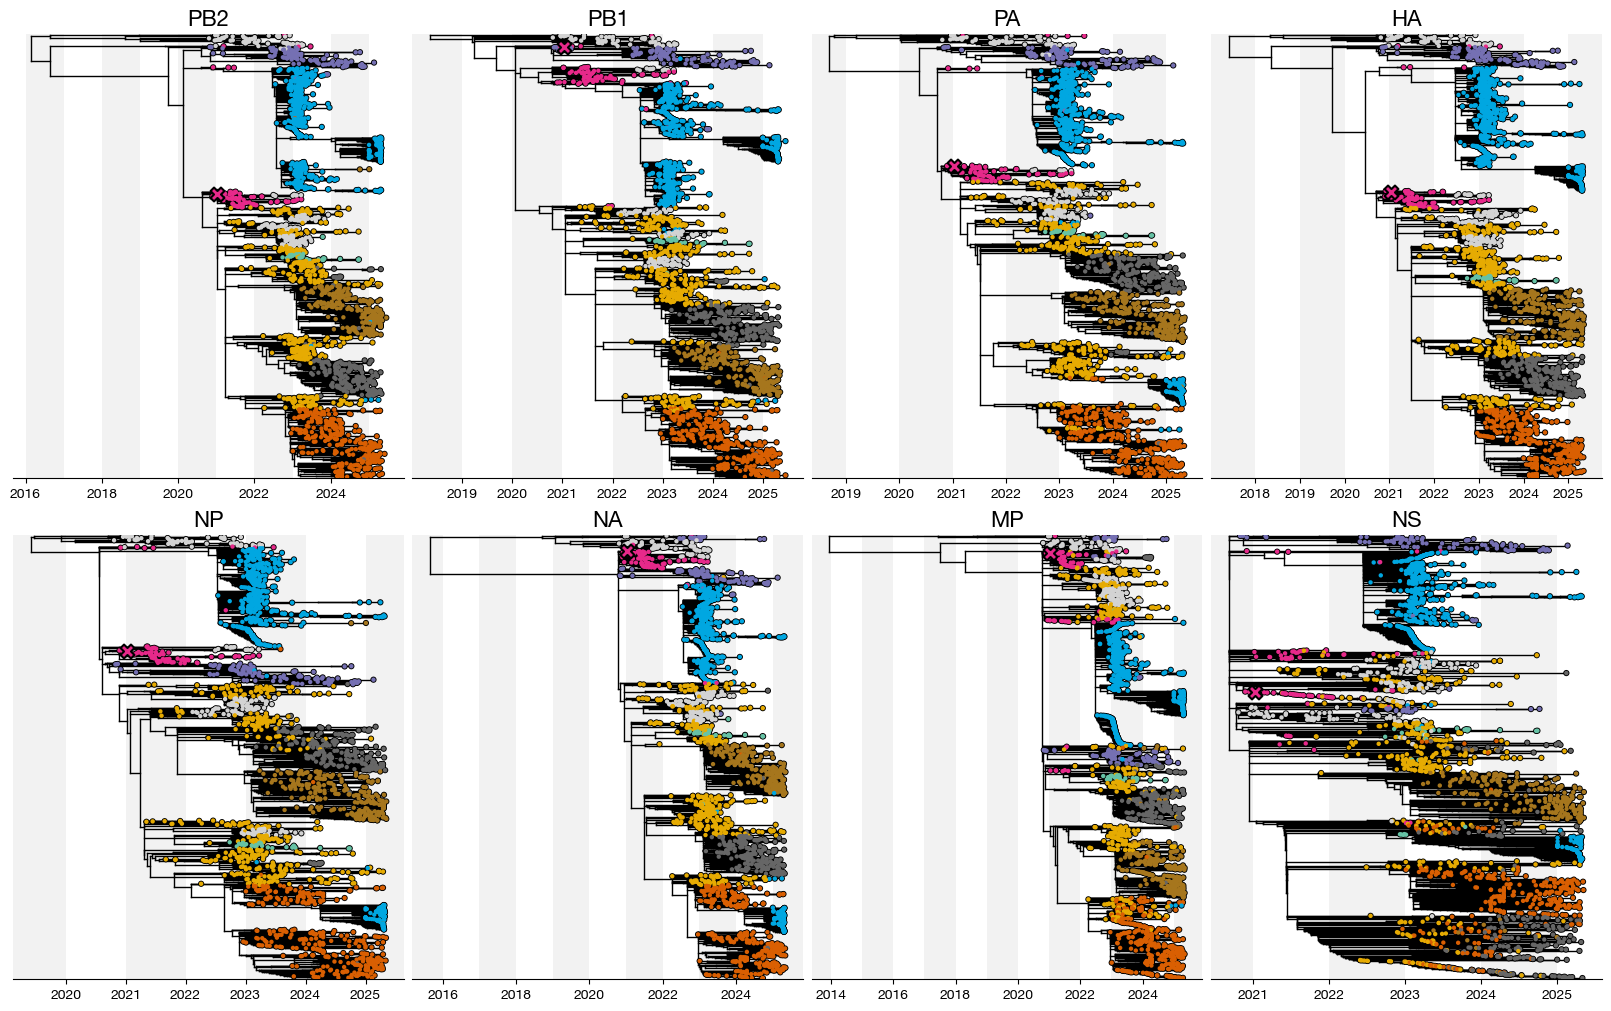

In [ ]:
import baltic as bt
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import datetime

# Global font settings
typeface = 'Helvetica Neue'
mpl.rcParams['font.weight'] = 300
mpl.rcParams['axes.labelweight'] = 300
mpl.rcParams['font.family'] = typeface
mpl.rcParams['font.size'] = 22

def plot_influenza_tree(
    tree_file,
    vaccine_strain="B/Austria/1359417/2021-E3(Am2/Al1)",
    subclade_colors=None,
    figsize=(3, 12),
    add_labels=False,
    label_distance=0.8,
    x_labelsize=14,
    ax=None,
    title=None
):
    if subclade_colors is None:
        subclade_colors = {
            "C.5.1": "#d95f02",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#00A7E1",
            "C.2": "#7570b3",
            "C": "#e7298a"
        }

    tree = bt.loadJSON(tree_file)

    def c_func(node):
        subclade = node.traits.get('subclade')
        return subclade_colors.get(subclade, 'lightgrey')

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, facecolor='w')

    x_attr = lambda k: k.absoluteTime
    tree[0].plotTree(ax, connection_type="baltic", x_attr=x_attr, colour='k', width=1)
    tree[0].plotPoints(ax, x_attr=x_attr, size=10, outline=True, outline_colour="black", colour=c_func, zorder=100)

    # Calculate date bounds from all nodes
    node_dates = [k.absoluteTime for k in tree[0].Objects if hasattr(k, 'absoluteTime')]
    min_year = int(min(node_dates))
    max_year = int(max(node_dates)) + 1

    # Add alternating year backgrounds
    for i, year in enumerate(range(min_year, max_year)):
        if i % 2 == 0:
            ax.axvspan(year, year + 1, facecolor='grey', alpha=0.1, edgecolor='none', zorder=0)

    # Mark vaccine strain
    for k in tree[0].Objects:
        if k.is_leaf() and k.name == vaccine_strain:
            ax.scatter(
                k.absoluteTime, k.y, s=100, marker='X',
                facecolor=subclade_colors["C"], edgecolor='black',
                linewidth=1.5, zorder=200
            )
            break

    # Optional labels
    if add_labels:
        max_x = max(k.absoluteTime for k in tree[0].Objects if k.is_leaf())
        label_x = max_x + label_distance
        for k in tree[0].Objects:
            if k.is_leaf():
                ax.plot([k.absoluteTime, label_x], [k.y, k.y], color='gray', linestyle=':', linewidth=1)
                ax.text(label_x + 0.1, k.y, k.name, va='center', ha='left', size=10, color='black')

    # Aesthetics
    ax.xaxis.tick_bottom()
    ax.set_ylim(-5, tree[0].ySpan + 5)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.tick_params(axis='x', labelsize=x_labelsize)
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    if title:
        ax.set_title(title, fontsize=16)

def plot_segment_grid(segment_paths, segment_names, figsize=(16, 10)):
    fig, axs = plt.subplots(2, 4, figsize=figsize, facecolor='w', constrained_layout=True)
    axs = axs.flatten()

    for i, (path, name) in enumerate(zip(segment_paths, segment_names)):
        plot_influenza_tree(
            tree_file=path,
            ax=axs[i],
            title=name,
            x_labelsize=10
        )

    plt.show()

# === Example usage ===
segment_paths = [
    "../auspice/vic/pb2.json",
    "../auspice/vic/pb1.json",
    "../auspice/vic/pa.json",
    "../auspice/vic/ha.json",
    "../auspice/vic/np.json",
    "../auspice/vic/na.json",
    "../auspice/vic/mp.json",
    "../auspice/vic/ns.json"
]
segment_names = ["PB2", "PB1", "PA", "HA", "NP", "NA", "MP", "NS"]

plot_segment_grid(segment_paths, segment_names)


## Add genome to the grid 


Tree height: 8.921817
Tree length: 1359.867001
annotations present

Numbers of objects in tree: 4625 (2290 nodes and 2335 leaves)


Tree height: 9.310130
Tree length: 1255.505661
annotations present

Numbers of objects in tree: 3857 (1522 nodes and 2335 leaves)


Tree height: 7.095150
Tree length: 1184.972572
annotations present

Numbers of objects in tree: 3831 (1496 nodes and 2335 leaves)


Tree height: 6.654375
Tree length: 1011.683817
annotations present

Numbers of objects in tree: 3992 (1657 nodes and 2335 leaves)


Tree height: 7.945229
Tree length: 1088.259765
annotations present

Numbers of objects in tree: 3984 (1649 nodes and 2335 leaves)


Tree height: 5.925137
Tree length: 1200.355876
annotations present

Numbers of objects in tree: 3992 (1657 nodes and 2335 leaves)


Tree height: 9.688370
Tree length: 1264.891625
annotations present

Numbers of objects in tree: 3828 (1493 nodes and 2335 leaves)


Tree height: 11.395142
Tree length: 1433.933887
annotations present

Number

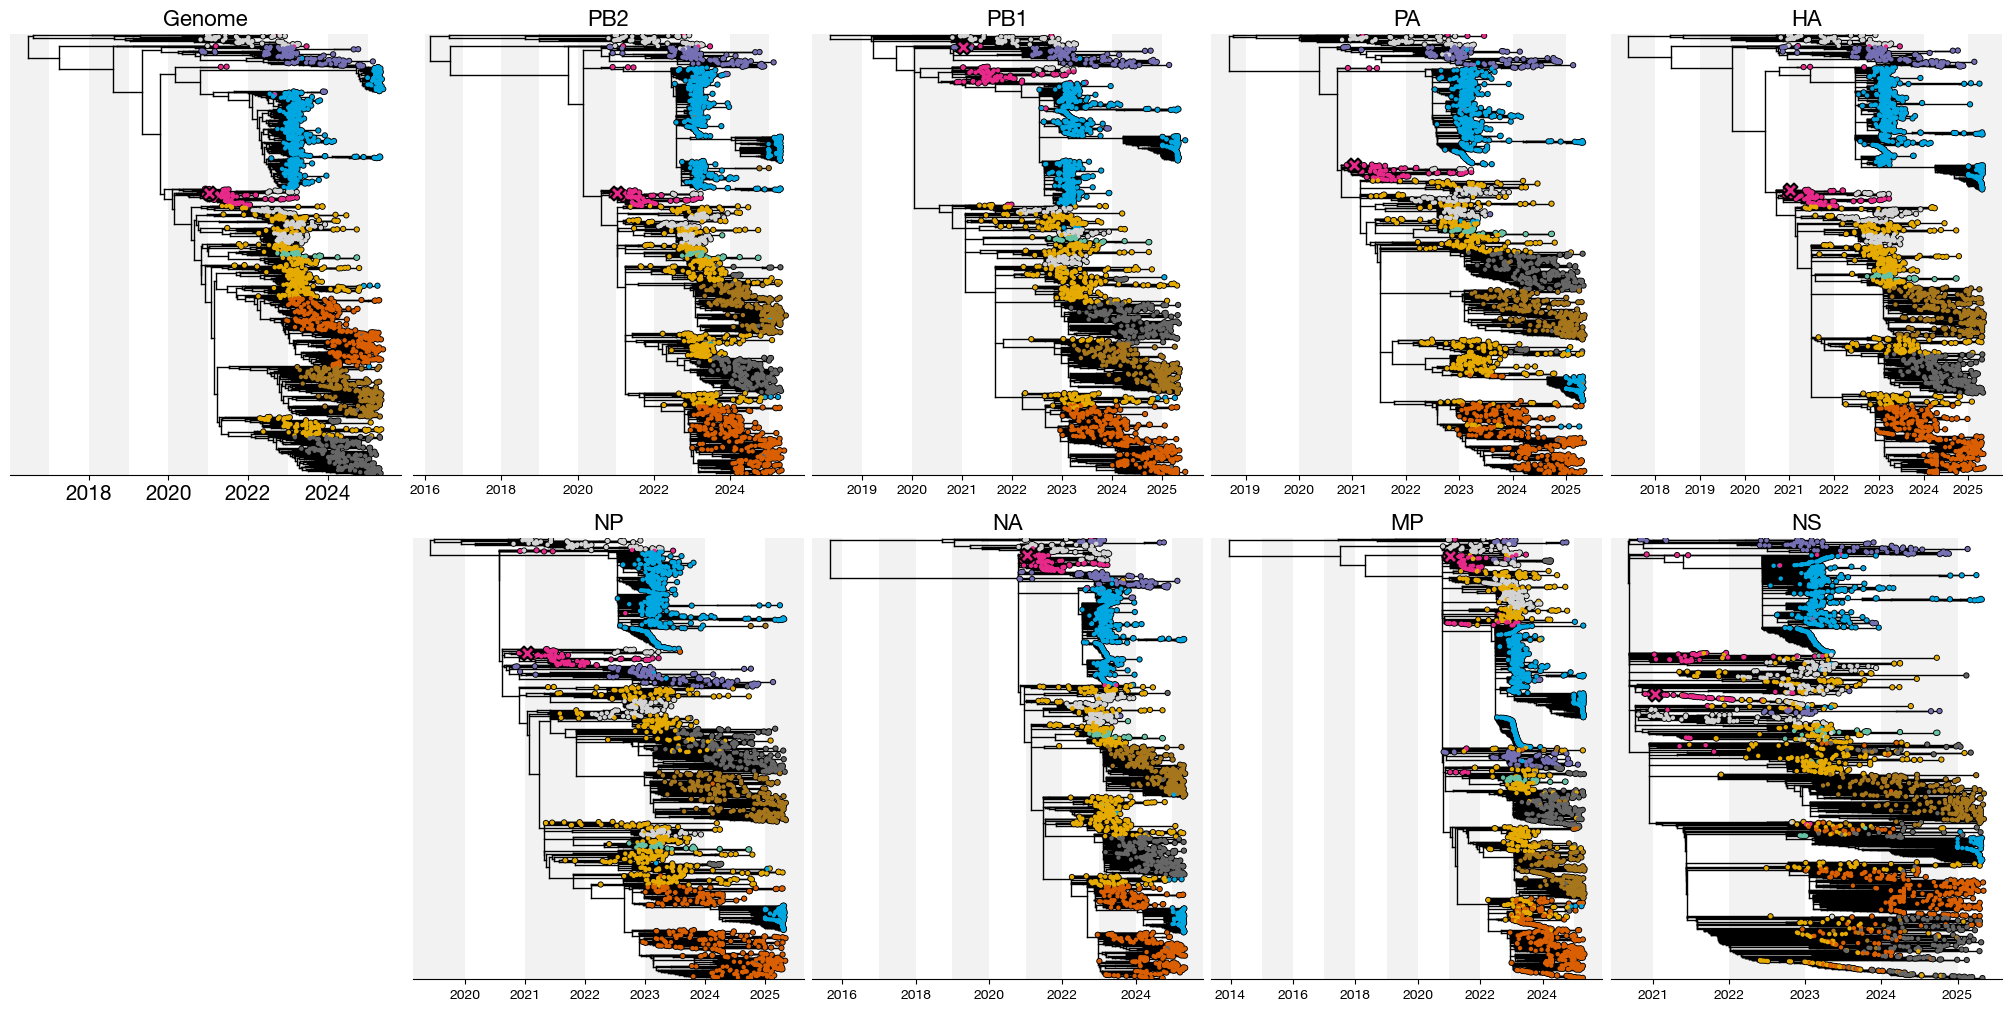

In [31]:
import baltic as bt
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import datetime

# Global font settings
typeface = 'Helvetica Neue'
mpl.rcParams['font.weight'] = 300
mpl.rcParams['axes.labelweight'] = 300
mpl.rcParams['font.family'] = typeface
mpl.rcParams['font.size'] = 22

def plot_influenza_tree(
    tree_file,
    vaccine_strain="B/Austria/1359417/2021-E3(Am2/Al1)",
    subclade_colors=None,
    figsize=(3, 12),
    add_labels=False,
    label_distance=0.8,
    x_labelsize=14,
    ax=None,
    title=None
):
    if subclade_colors is None:
        subclade_colors = {
            "C.5.1": "#d95f02",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#00A7E1",
            "C.2": "#7570b3",
            "C": "#e7298a"
        }

    tree = bt.loadJSON(tree_file)

    def c_func(node):
        subclade = node.traits.get('subclade')
        return subclade_colors.get(subclade, 'lightgrey')

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, facecolor='w')

    x_attr = lambda k: k.absoluteTime
    tree[0].plotTree(ax, connection_type="baltic", x_attr=x_attr, colour='k', width=1)
    tree[0].plotPoints(ax, x_attr=x_attr, size=10, outline=True, outline_colour="black", colour=c_func, zorder=100)

    # Calculate date bounds from all nodes
    node_dates = [k.absoluteTime for k in tree[0].Objects if hasattr(k, 'absoluteTime')]
    min_year = int(min(node_dates))
    max_year = int(max(node_dates)) + 1

    for i, year in enumerate(range(min_year, max_year)):
        if i % 2 == 0:
            ax.axvspan(year, year + 1, facecolor='grey', alpha=0.1, edgecolor='none', zorder=0)

    # Mark vaccine strain
    for k in tree[0].Objects:
        if k.is_leaf() and k.name == vaccine_strain:
            ax.scatter(
                k.absoluteTime, k.y, s=100, marker='X',
                facecolor=subclade_colors["C"], edgecolor='black',
                linewidth=1.5, zorder=200
            )
            break

    if add_labels:
        max_x = max(k.absoluteTime for k in tree[0].Objects if k.is_leaf())
        label_x = max_x + label_distance
        for k in tree[0].Objects:
            if k.is_leaf():
                ax.plot([k.absoluteTime, label_x], [k.y, k.y], color='gray', linestyle=':', linewidth=1)
                ax.text(label_x + 0.1, k.y, k.name, va='center', ha='left', size=15, color='black')

    ax.xaxis.tick_bottom()
    ax.set_ylim(-5, tree[0].ySpan + 5)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.tick_params(axis='x', labelsize=x_labelsize)
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    if title:
        ax.set_title(title, fontsize=16)

def plot_segment_grid_with_genome(segment_paths, segment_names, genome_path, figsize=(20, 10)):
    fig, axs = plt.subplots(2, 5, figsize=figsize, facecolor='w', constrained_layout=True)
    axs = axs.flatten()

    # Plot genome tree in top-left (index 0)
    plot_influenza_tree(
        tree_file=genome_path,
        ax=axs[0],
        title="Genome",
        x_labelsize=15
    )

    # Skip axs[5] (bottom-left, 1st col 2nd row) — index 5
    skip_index = 5
    seg_idx = 0
    for i in range(1, len(axs)):
        if i == skip_index:
            axs[i].axis('off')  # Leave blank
            continue
        if seg_idx < len(segment_paths):
            plot_influenza_tree(
                tree_file=segment_paths[seg_idx],
                ax=axs[i],
                title=segment_names[seg_idx],
                x_labelsize=10
            )
            seg_idx += 1

    plt.show()

# === Usage ===
segment_paths = [
    "../auspice/vic/pb2.json",
    "../auspice/vic/pb1.json",
    "../auspice/vic/pa.json",
    "../auspice/vic/ha.json",
    "../auspice/vic/np.json",
    "../auspice/vic/na.json",
    "../auspice/vic/mp.json",
    "../auspice/vic/ns.json"
]
segment_names = ["PB2", "PB1", "PA", "HA", "NP", "NA", "MP", "NS"]
genome_path = "../auspice/vic/genome.json"

plot_segment_grid_with_genome(segment_paths, segment_names, genome_path)


## Collapse Subclades

Lets write a function to collapse subclades...or at least attempt



Tree height: 7.945229
Tree length: 1088.259765
annotations present

Numbers of objects in tree: 3984 (1649 nodes and 2335 leaves)



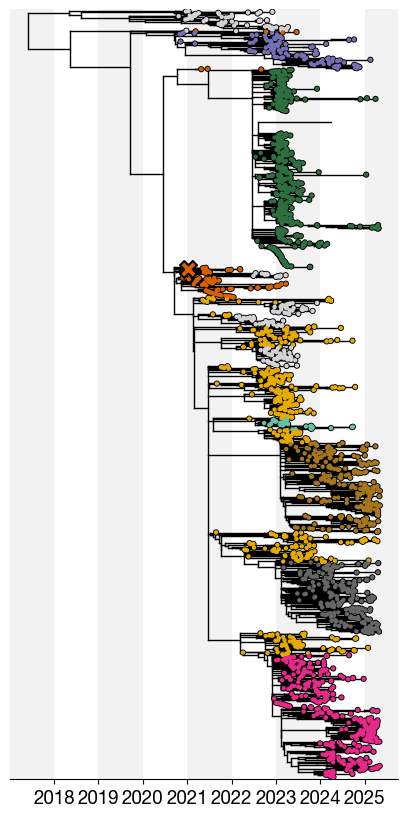


Tree height: 7.945229
Tree length: 1088.259765
annotations present

Numbers of objects in tree: 3984 (1649 nodes and 2335 leaves)



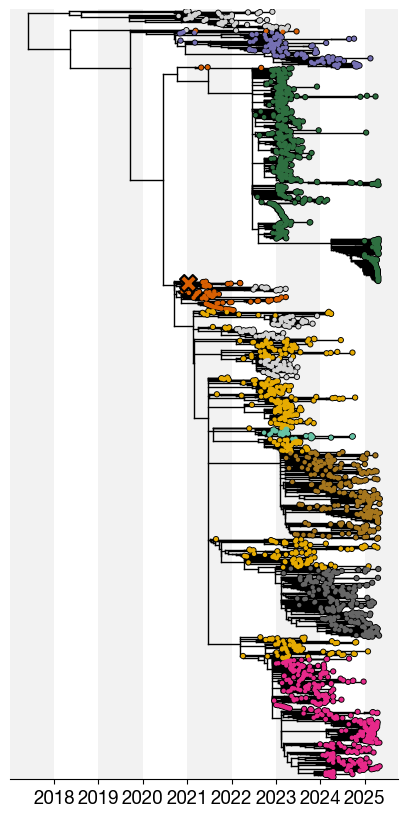

In [ ]:
import baltic as bt
import matplotlib as mpl
import matplotlib.pyplot as plt

# Set global fonts once (can be done outside the function)
typeface = 'Helvetica Neue'
mpl.rcParams['font.weight'] = 200
mpl.rcParams['axes.labelweight'] = 300
mpl.rcParams['font.family'] = typeface
mpl.rcParams['font.size'] = 22

def plot_influenza_tree(
    tree_file,
    vaccine_strain="B/Austria/1359417/2021-E3(Am2/Al1)",
    subclade_colors=None,
    figsize=(5, 10),
    add_labels=False,
    label_distance=0.8,
    x_labelsize=14,
    collapse_nodes=None  # List of internal node names or lists of tip names for commonAncestor
):
    # Default subclade color palette if none provided
    if subclade_colors is None:
        subclade_colors = {
            "C.5.1": "#d95f02",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#00A7E1",
            "C.2": "#7570b3",
            "C": "#e7298a"
        }
    
    # Load tree
    tree_obj = bt.loadJSON(tree_file)
    tree = tree_obj[0]

    # Reset any prior collapses
    tree.uncollapseSubtree()

    # Collapse specified nodes if provided
    if collapse_nodes:
        for node_spec in collapse_nodes:
            if isinstance(node_spec, str):
                # Collapse by internal node name directly
                internal_nodes = [n for n in tree.getInternal() if n.name == node_spec]
                if internal_nodes:
                    node = internal_nodes[0]
                    tree.collapseSubtree(node, f"Collapsed {node.name}", widthFunction=lambda x: len(x.leaves) / 2)
            elif isinstance(node_spec, (list, tuple)):
                # Collapse by common ancestor of tips
                leaves = tree.getExternal(lambda k: k.name in node_spec)
                if leaves:
                    ancestor = tree.commonAncestor(leaves)
                    tree.collapseSubtree(ancestor, f"Collapsed {ancestor.name}", widthFunction=lambda x: len(x.leaves) / 2)

    # Define color function for tips by subclade
    def c_func(node):
        subclade = node.traits.get('subclade')
        return subclade_colors.get(subclade, 'lightgrey')

    # Prepare figure and axis
    fig, ax = plt.subplots(figsize=figsize, facecolor='w')

    x_attr = lambda k: k.absoluteTime

    # Plot tree branches
    tree.plotTree(ax, connection_type="baltic", x_attr=x_attr, colour='k', width=1)
    # Plot tips colored by subclade
    tree.plotPoints(ax, x_attr=x_attr, size=10, outline=True, outline_colour="black", colour=c_func, zorder=100)

    # Get min and max year from all nodes (tips + internal)
    all_dates = [k.absoluteTime for k in tree.Objects]
    min_year = int(min(all_dates))
    max_year = int(max(all_dates)) + 1

    # Add alternating grey and white background bars by year
    for i, year in enumerate(range(min_year, max_year)):
        if i % 2 == 0:
            ax.axvspan(year, year + 1, facecolor='grey', alpha=0.1, edgecolor='none')
        else:
            ax.axvspan(year, year + 1, facecolor='white', alpha=0, edgecolor='none')

    # Set x-axis ticks and labels as years
    years = list(range(min_year, max_year))
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years])

    # Highlight vaccine strain tip
    for k in tree.Objects:
        if k.is_leaf() and k.name == vaccine_strain:
            x = k.absoluteTime
            y = k.y
            ax.scatter(
                x, y,
                s=150,
                marker='X',
                facecolors="#d95f02",
                edgecolors='black',
                linewidths=1.5,
                zorder=200
            )
            break

    # Optionally add labels with connecting lines (not active by default)
    if add_labels:
        max_x = max(k.absoluteTime for k in tree.Objects if k.is_leaf())
        label_x = max_x + label_distance
        for k in tree.Objects:
            if k.is_leaf():
                ax.plot([k.absoluteTime, label_x], [k.y, k.y], color='gray', linestyle=':', linewidth=1)
                ax.text(label_x + 0.1, k.y, k.name, va='center', ha='left', size=10, color='black')

    # Aesthetics cleanup
    ax.xaxis.tick_bottom()
    ax.tick_params(axis='x', labelsize=x_labelsize)
    ax.set_ylim(-5, tree.ySpan + 5)
    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]

    plt.show()

plot_influenza_tree("../auspice/vic/ha.json", collapse_nodes=["NODE_0002205"], x_labelsize=13.5)
plot_influenza_tree("../auspice/vic/ha.json", x_labelsize=13.5)


## Tanglegram


> Copy over all auspice json's to a new sub-directory for easly looping and plotting


Sources: 
- https://github.com/dven42/phylogenetic-incongruence/blob/master/BALTIC.ipynb
- https://journals.plos.org/plospathogens/article?id=10.1371/journal.ppat.1006466
- https://github.com/blab/siv-cst/blob/master/figures/main-text/F1-recombination.ipynb

## Import Trees

In [1]:
import baltic as bt
from glob import glob
from IPython.display import HTML
import re
import copy

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon

import numpy as np
from scipy.special import binom
import itertools
import requests

from io import StringIO as sio
from io import BytesIO as csio

from Bio import Phylo


treefiles = glob('../auspice/plotting/*.json')


segments=['PB1','PB2','PA','HA','NP','NA','MP','NS']

trees={} ## dict
for segment in segments:
    print(segment, )
    tree_location = f"../auspice/vic/{segment}.json"

    ll = bt.loadJSON(tree_location)
    trees[segment]=ll[0] ## add ONLY the tree object to dict

print('\nDone!')

PB1

Tree height: 6.323000
Tree length: 1180.957000
annotations present

Numbers of objects in tree: 3839 (1504 nodes and 2335 leaves)

PB2

Tree height: 9.586000
Tree length: 1269.608000
annotations present

Numbers of objects in tree: 3849 (1514 nodes and 2335 leaves)

PA

Tree height: 7.130000
Tree length: 1008.749000
annotations present

Numbers of objects in tree: 3985 (1650 nodes and 2335 leaves)

HA

Tree height: 7.721000
Tree length: 1112.699000
annotations present

Numbers of objects in tree: 3954 (1619 nodes and 2335 leaves)

NP

Tree height: 5.923000
Tree length: 1196.359000
annotations present

Numbers of objects in tree: 3975 (1640 nodes and 2335 leaves)

NA

Tree height: 9.116000
Tree length: 1279.125000
annotations present

Numbers of objects in tree: 3827 (1492 nodes and 2335 leaves)

MP

Tree height: 11.177000
Tree length: 1445.449000
annotations present

Numbers of objects in tree: 4022 (1687 nodes and 2335 leaves)

NS

Tree height: 4.668000
Tree length: 1584.112000
a

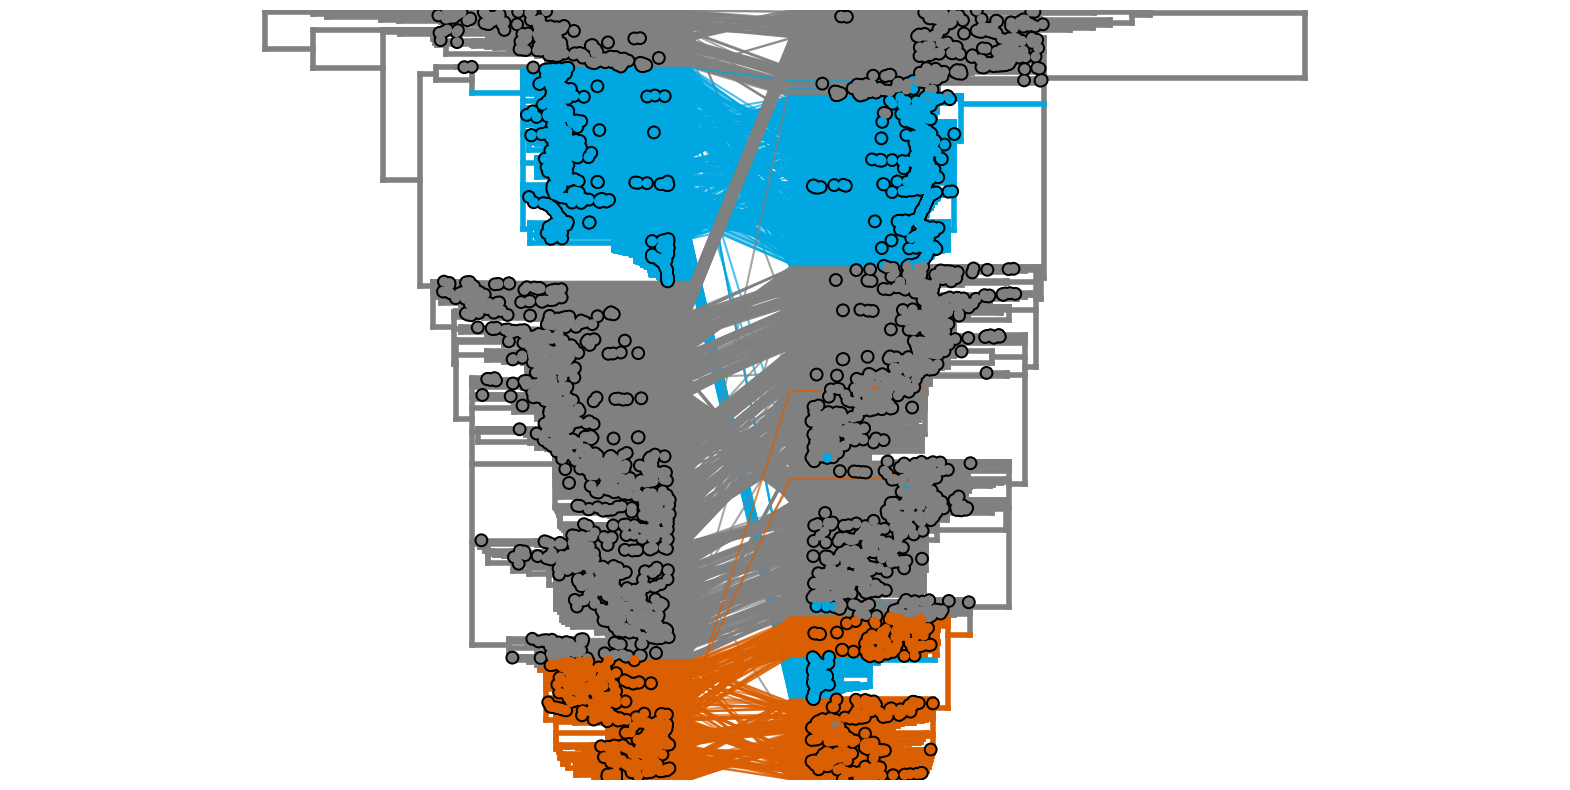

In [11]:
# Plot a tanglegram between PB1 and PB2, coloring by subclade

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

# Set up figure and axes
fig = plt.figure(figsize=(20, 10), facecolor='w')
gs = GridSpec(1, 1, hspace=0.0, wspace=0.0)
ax = plt.subplot(gs[0])

traitName = 'subclade'
tree1 = trees["HA"]
tree2 = trees["NA"]

# Color function for subclade
subclade_colors = {
    "C.3": "#00A7E1",
    "C.5.1": "#d95f02"
}
def c_func(k):
    return subclade_colors.get(k.traits.get(traitName), 'grey')


cmap = mpl.cm.cividis
x_attr1 = lambda k: k.height

# Plot first tree
tree1.plotTree(ax, x_attr=x_attr1, width=4, colour=c_func)
tree1.plotPoints(ax, x_attr=x_attr1, size=50, colour=c_func, zorder=100)

# Offset for second tree
skip = tree1.treeHeight * 0.35
x_attr2 = lambda k: tree1.treeHeight + skip + tree2.treeHeight - k.height

# Plot second tree
tree2.plotTree(ax, x_attr=x_attr2, width=4, colour=c_func)
tree2.plotPoints(ax, x_attr=x_attr2, size=50, colour=c_func, zorder=100)

# Draw tangle lines between matching tips
for k in filter(lambda x: x.branchType == 'leaf', tree1.Objects):
    x = k.height
    y = k.y
    # Set warn=False to avoid exceptions if no match is found
    matching = tree2.getBranches(lambda x2: x2.branchType == 'leaf' and x2.name == k.name, warn=False)
    if not matching:
        continue
    # Handle both list and single object return types
    if isinstance(matching, list):
        matching_tip = matching[0]
    else:
        matching_tip = matching
    match_y = matching_tip.y
    xs = [x, tree1.treeHeight + 0.15 * skip, tree1.treeHeight + skip - 0.15 * skip, x_attr2(matching_tip)]
    ys = [y, y, match_y, match_y]
    color = subclade_colors.get(k.traits.get(traitName), 'grey')
    ax.plot(xs, ys, color=color, alpha=0.7)

# Clean up plot aesthetics
for loc in ['top', 'right', 'left', 'bottom']:
    ax.spines[loc].set_visible(False)
ax.tick_params(axis='x', size=0)
ax.tick_params(axis='y', size=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_ylim(-1, tree1.ySpan + 1)
ax.set_xlim(-5, tree1.treeHeight + skip + tree2.treeHeight + 5)

plt.show()

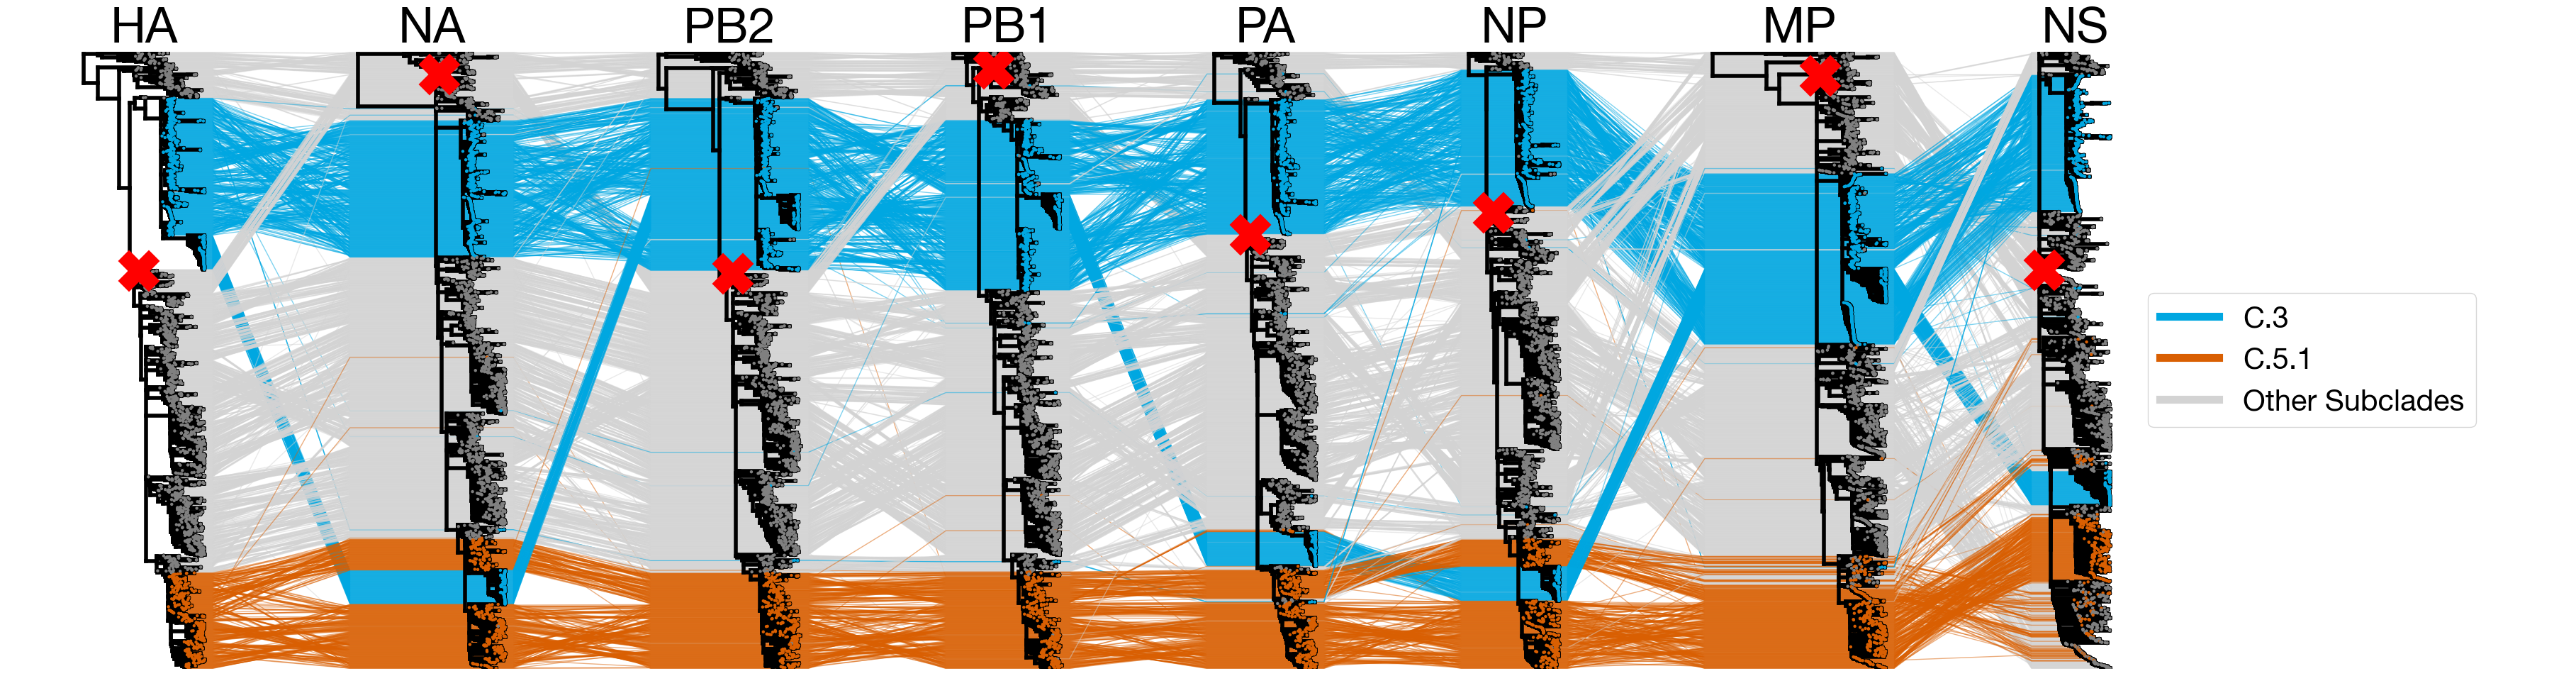

In [20]:
# adjust some of the aesthetics 
import baltic as bt
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Set up figure
fig, ax = plt.subplots(figsize=(40, 10), facecolor='w')

traitName = 'subclade'
cumulative_displace = 0
displaceAmount = 10

tree_names = ['HA', 'NA', 'PB2', 'PB1', 'PA', 'NP', 'MP', 'NS']

subclade_colors = {'C.3': "#00A7E1", 'C.5.1': "#d95f02"}

'''
subclade_colors = {
            "C.5.1": "#d95f02",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#00A7E1",
            "C.2": "#7570b3",
            "C": "#e7298a"
        }
'''



# ---- Precompute tip positions for each tree ----
tip_positions = {}
for tr in tree_names:
    tree = trees[tr]
    positions = {}
    for k in tree.Objects:
        if k.branchType == 'leaf':
            positions[k.name] = (k.height, k.y)
    tip_positions[tr] = positions

# ---- Plot each tree ----
for t, tr in enumerate(tree_names):
    cur_tree = trees[tr]
    x_attr = lambda k: k.height + cumulative_displace

    # Tree segment label above the tree
    ax.text(
        cumulative_displace + cur_tree.treeHeight / 2,
        cur_tree.ySpan + 1.5,
        tr,
        ha='center',
        va='bottom',
        fontsize=50,  # Increased font size
        fontweight='bold'
    )

    # Color function
    def colour_func(node):
        return subclade_colors.get(node.traits.get(traitName), 'grey')
    
    cur_tree.plotTree(ax, x_attr=x_attr, width=4, colour="black")
    cur_tree.plotPoints(ax, x_attr=x_attr, size=10, colour=colour_func, zorder=100)

    # Custom marker for tip "JH23663"
    for k in cur_tree.Objects:
        if k.branchType == 'leaf' and k.name == "B/Austria/1359417/2021-E3(Am2/Al1)":
            ax.plot(
                x_attr(k), k.y, marker='X', markersize=40, 
                color="red", markeredgewidth=1.5, zorder=200
            )

    # Draw linking lines to next tree
    if t != len(tree_names) - 1:
        next_tree = tree_names[t + 1]
        for k in cur_tree.Objects:
            if k.branchType == 'leaf' and k.name in tip_positions[next_tree]:
                y = k.y
                next_x, next_y = tip_positions[next_tree][k.name]
                next_x += cumulative_displace + cur_tree.treeHeight + displaceAmount
                nextIncrement = cumulative_displace + cur_tree.treeHeight
                color = subclade_colors.get(k.traits.get(traitName), 'lightgrey')
                ax.plot(
                    [x_attr(k), nextIncrement + 0.05 * displaceAmount,
                     nextIncrement + 0.95 * displaceAmount, next_x],
                    [y, y, next_y, next_y],
                    lw=1, ls='-', color=color, alpha=0.5,
                    zorder=0  # Always behind tips
                )

    cumulative_displace += cur_tree.treeHeight + displaceAmount

# ---- Final formatting ----
[ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left', 'bottom']]
ax.tick_params(axis='x', size=0)
ax.tick_params(axis='y', size=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_ylim(-1, cur_tree.ySpan + 2)
ax.set_xlim(-5, cumulative_displace + 20)

# ---- Dynamic Legend on the Right ----
legend_elements = [
    Line2D([0], [0], color=color, lw=8, label=subclade)  # thicker bars
    for subclade, color in subclade_colors.items()
]

legend_elements.append(Line2D([0], [0], color='lightgrey', lw=8, label='Other Subclades')) 

ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(0.83, 0.5),
    fontsize=30,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

# New Tanglegram Function: Add multiple tip shapes



Update legend formatting

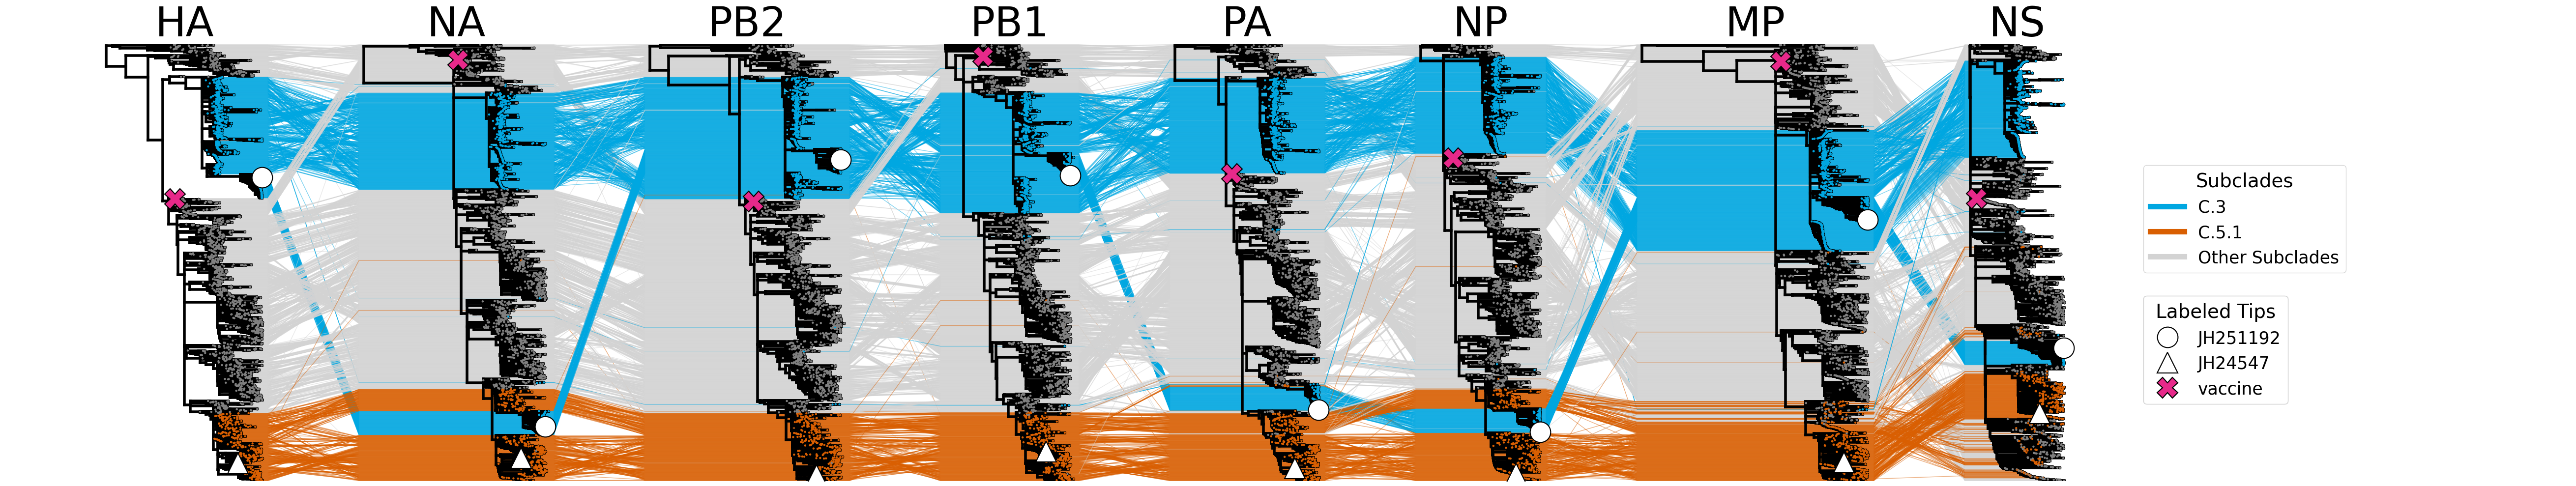

In [11]:
# adjust some of the aesthetics 
import baltic as bt
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Set up figure
fig, ax = plt.subplots(figsize=(35, 10), facecolor='w')

traitName = 'subclade'
cumulative_displace = 0
displaceAmount = 5

tree_names = ['HA', 'NA', 'PB2', 'PB1', 'PA', 'NP', 'MP', 'NS']

subclade_colors = {'C.3': "#00A7E1", 'C.5.1': "#d95f02"}

tip_shapes = {
    "JH251192": {
        "marker": "o",          # Circle
        "facecolor": "white",
        "edgecolor": "black",
        "markersize": 30
    },
    "JH24547": {
        "marker": "^",          # Upward triangle
        "facecolor": "white",
        "edgecolor": "black",
        "markersize": 30
    },
    "B/Austria/1359417/2021-E3(Am2/Al1)": {
        "marker": "X",          # X shape
        "facecolor": "#e7298a",   # Fill color
        "edgecolor": "black",   # Outline color
        "markersize": 30
    }
}

# ---- Precompute tip positions for each tree ----
tip_positions = {}
for tr in tree_names:
    tree = trees[tr]
    positions = {}
    for k in tree.Objects:
        if k.branchType == 'leaf':
            positions[k.name] = (k.height, k.y)
    tip_positions[tr] = positions

# ---- Plot each tree ----
for t, tr in enumerate(tree_names):
    cur_tree = trees[tr]
    x_attr = lambda k: k.height + cumulative_displace

    # Tree segment label
    ax.text(
        cumulative_displace + cur_tree.treeHeight / 2,
        cur_tree.ySpan + 1.5,
        tr,
        ha='center',
        va='bottom',
        fontsize=60,
        fontweight='normal'
    )

    def colour_func(node):
        return subclade_colors.get(node.traits.get(traitName), 'grey')
    
    cur_tree.plotTree(ax, x_attr=x_attr, width=4, colour="black")
    cur_tree.plotPoints(ax, x_attr=x_attr, size=10, colour=colour_func, zorder=100)

    # Plot special markers
    for k in cur_tree.Objects:
        if k.branchType == 'leaf' and k.name in tip_shapes:
            shape = tip_shapes[k.name]
            ax.plot(
                x_attr(k), k.y,
                marker=shape.get("marker", "o"),
                markerfacecolor=shape.get("facecolor", "white"),
                markeredgecolor=shape.get("edgecolor", "black"),
                markeredgewidth=shape.get("markeredgewidth", 1.5),
                markersize=shape.get("markersize", 20),
                linestyle='None',
                zorder=shape.get("zorder", 200)
            )

    # Draw linking lines
    if t != len(tree_names) - 1:
        next_tree = tree_names[t + 1]
        for k in cur_tree.Objects:
            if k.branchType == 'leaf' and k.name in tip_positions[next_tree]:
                y = k.y
                next_x, next_y = tip_positions[next_tree][k.name]
                next_x += cumulative_displace + cur_tree.treeHeight + displaceAmount
                nextIncrement = cumulative_displace + cur_tree.treeHeight
                color = subclade_colors.get(k.traits.get(traitName), 'lightgrey')
                ax.plot(
                    [x_attr(k), nextIncrement + 0.05 * displaceAmount,
                     nextIncrement + 0.95 * displaceAmount, next_x],
                    [y, y, next_y, next_y],
                    lw=1, ls='-', color=color, alpha=0.5,
                    zorder=0
                )

    cumulative_displace += cur_tree.treeHeight + displaceAmount

# ---- Final formatting ----
[ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left', 'bottom']]
ax.tick_params(axis='x', size=0)
ax.tick_params(axis='y', size=0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_ylim(-1, cur_tree.ySpan + 2)
ax.set_xlim(-5, cumulative_displace + 20)

# ---- Build two legends ----

# Subclade color legend
legend_clades = [
    Line2D([0], [0], color=color, lw=8, label=subclade)
    for subclade, color in subclade_colors.items()
]
legend_clades.append(
    Line2D([0], [0], color='lightgrey', lw=8, label='Other Subclades')
)

# Tip shape legend
legend_shapes = [
    Line2D(
        [0], [0],
        marker=shape.get("marker", "o"),
        label=("vaccine" if tip == "B/Austria/1359417/2021-E3(Am2/Al1)" else tip),
        markerfacecolor=shape.get("facecolor", "white"),
        markeredgecolor=shape.get("edgecolor", "black"),
        markeredgewidth=1.5,
        markersize=shape.get("markersize", 20),
        linestyle='None',
        color='w'
    )
    for tip, shape in tip_shapes.items()
]
# Add both legends stacked vertically
legend1 = ax.legend(
    handles=legend_clades,
    loc='center left',
    bbox_to_anchor=(0.83, 0.6),
    fontsize=25,
    frameon=True,
    title="Subclades",
    title_fontsize=28
)

legend2 = ax.legend(
    handles=legend_shapes,
    loc='center left',
    bbox_to_anchor=(0.83, 0.3),
    fontsize=25,
    frameon=True,
    title="Labeled Tips",
    title_fontsize=28
)

ax.add_artist(legend1)
ax.add_artist(legend2)

plt.savefig(
    "../figures/tanglegram.png",    
    dpi=300,           
    bbox_inches='tight',
    transparent=False, 
    facecolor='white' 
)

plt.tight_layout(rect=[0, 0, 1.5, 1])
plt.show()


# Calculating tMRCA between C.3 and C.3re by segment

## HA 

In [9]:
myTree, mymeta = bt.loadJSON("../auspice/vic/ha.json")
tmrca_matrix = myTree.allTMRCAs()


Tree height: 7.812662
Tree length: 1225.729473
annotations present

Numbers of objects in tree: 4328 (1828 nodes and 2500 leaves)



In [ ]:
tip1, tip2 = "JH251192", "JH24547" #JH251289 = C.3 , JH251043=C.5.1 
print(f"TMRCA between {tip1} and {tip2}: {tmrca_matrix[tip1][tip2]}")


TMRCA between JH251289 and JH251043: 2020.0531689328477


# Identify MRCA of C.3, C.3re and C.5.1 

In [8]:
#https://github.com/evogytis/baltic/wiki/Method-%60baltic.tree.commonAncestor%60

# Representatives for: 
# C.3 
# C.3re 
# C.5.1


# Assuming we have a tree and some leaf nodes
leaf1 = myTree.getExternal()[0]
leaf2 = myTree.getExternal()[5]
leaf3 = myTree.getExternal()[10]

# Find the common ancestor of these three leaves
mrca = myTree.commonAncestor([leaf1, leaf2, leaf3])

mrca
print(f"Common ancestor index: {mrca.index}")
print(f"Height of common ancestor: {mrca.height}")

# We can also use this to check if a set of leaves form a monophyletic group
all_leaves = myTree.getExternal()
group_of_interest = all_leaves[:5]  # First 5 leaves
mrca_of_group = myTree.commonAncestor(group_of_interest)

is_monophyletic = set(mrca_of_group.leaves) == set(leaf.name for leaf in group_of_interest)
print(f"Is the group monophyletic? {is_monophyletic}")



NameError: name 'myTree' is not defined